In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import fbeta_score, f1_score, precision_score, recall_score, precision_recall_curve
from sklearn.ensemble import ExtraTreesClassifier
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

In [37]:
# Đọc các tập dữ liệu
demographic = pd.read_csv('data/demographic.csv')
examination = pd.read_csv('data/examination.csv')
labs = pd.read_csv('data/labs.csv')
questionnaire = pd.read_csv('data/questionnaire.csv')
diet = pd.read_csv('data/diet.csv')
# medications = pd.read_csv('data/medications.csv') # File thuốc chủ yếu dùng cho Tra cứu, có thể bỏ qua trong huấn luyện ML

# Gộp dữ liệu dựa trên mã định danh SEQN
df = demographic.merge(examination, on='SEQN', how='inner')
df = df.merge(labs, on='SEQN', how='inner')
df = df.merge(questionnaire, on='SEQN', how='inner')
df = df.merge(diet, on='SEQN', how='inner')

print(f"Kích thước dữ liệu sau khi gộp: {df.shape}")

Kích thước dữ liệu sau khi gộp: (9813, 1812)


In [38]:
# 1. Tạo biến mục tiêu (Target)
# DIQ010: 1.0 (Có bệnh), 2.0 (Không bệnh), 3.0 (Tiền đái tháo đường)
# Dựa theo báo cáo, tỷ lệ positive là ~7.55% tương ứng với DIQ010 == 1.0
df = df.dropna(subset=['DIQ010']) # Bỏ các dòng thiếu nhãn
df['Target'] = df['DIQ010'].apply(lambda x: 1 if x == 1.0 else 0)

print("Phân phối nhãn mục tiêu:")
print(df['Target'].value_counts(normalize=True) * 100)

# 2. Lựa chọn các đặc trưng (Feature Selection)
# Chọn các biến quan trọng như trong báo cáo (có thể thêm bớt tùy theo tên cột thực tế của bạn)
features = [
    'RIDAGEYR', 'RIAGENDR', # Nhân khẩu học: Tuổi, Giới tính
    'BMXBMI', 'BMXWAIST', 'BPXSY1', 'BPXDI1', # Thể trạng: BMI, Vòng eo, Huyết áp tâm thu/trương
    'LBXSGL', 'LBXGH', 'LBXTC', 'LBDLDL', 'LBXSCR', # Xét nghiệm: Glucose, HbA1c, Chol, LDL, Creatinine
    'SMQ020', 'PAQ650', 'ALQ130', # Lối sống: Hút thuốc, Vận động, Rượu bia
    'DR1TKCAL', 'DR1TSODI' # Dinh dưỡng: Kcal, Muối
]

# Đảm bảo các cột feature tồn tại trong dataframe (lọc ra các cột có sẵn)
available_features = [f for f in features if f in df.columns]

X = df[available_features]
y = df['Target']

Phân phối nhãn mục tiêu:
Target
0    92.33627
1     7.66373
Name: proportion, dtype: float64


In [39]:
# Chia tập train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline tiền xử lý (Preprocessing)
preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Điền khuyết bằng trung vị
    ('scaler', StandardScaler())                   # Chuẩn hóa thang đo
])

# Fit và Transform trên tập Train, chỉ Transform trên tập Test
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print("Tiền xử lý hoàn tất!")

Tiền xử lý hoàn tất!


In [40]:
def find_optimal_threshold(y_true, y_probs, beta=0.75):
    """
    Tìm ngưỡng tối ưu dựa trên chỉ số F-beta
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
    fbeta_scores = ((1 + beta**2) * (precisions * recalls)) / ((beta**2 * precisions) + recalls)
    
    # Bỏ qua các giá trị NaN nếu có
    fbeta_scores = np.nan_to_num(fbeta_scores)
    
    optimal_idx = np.argmax(fbeta_scores)
    optimal_threshold = thresholds[optimal_idx]
    
    return optimal_threshold

def evaluate_model(model_name, y_true, y_probs, threshold):
    """
    Đánh giá mô hình dựa trên ngưỡng tùy chỉnh
    """
    y_pred = (y_probs >= threshold).astype(int)
    print(f"=== {model_name} ===")
    print(f"-> Optimal threshold: {threshold:.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print("-" * 30)

In [41]:
# Cài đặt mô hình
et_model = ExtraTreesClassifier(
    n_estimators=600, 
    class_weight='balanced', # Xử lý mất cân bằng nhẹ
    random_state=42,
    n_jobs=-1
)

# Huấn luyện
et_model.fit(X_train_preprocessed, y_train)

# Dự báo xác suất (Probability)
y_probs_et = et_model.predict_proba(X_test_preprocessed)[:, 1]

# Tìm ngưỡng và đánh giá
opt_thresh_et = find_optimal_threshold(y_test, y_probs_et, beta=0.75)
evaluate_model("Extra Trees", y_test, y_probs_et, opt_thresh_et)

=== Extra Trees ===
-> Optimal threshold: 0.4000
F1-Score:  0.6923
Recall:    0.6250
Precision: 0.7759
------------------------------


In [42]:
# Tính scale_pos_weight tự động hoặc set cứng bằng 12.24 như trong báo cáo
# scale_weight = (len(y_train) - sum(y_train)) / sum(y_train) 

xgb_model = xgb.XGBClassifier(
    learning_rate=0.05,
    scale_pos_weight=12.24, # Thông số then chốt từ đồ án
    n_estimators=300,
    max_depth=6,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42
)

# Huấn luyện
xgb_model.fit(X_train_preprocessed, y_train)

# Dự báo xác suất
y_probs_xgb = xgb_model.predict_proba(X_test_preprocessed)[:, 1]

# Tìm ngưỡng và đánh giá
opt_thresh_xgb = find_optimal_threshold(y_test, y_probs_xgb, beta=0.75)
evaluate_model("XGBoost", y_test, y_probs_xgb, opt_thresh_xgb)

=== XGBoost ===
-> Optimal threshold: 0.6879
F1-Score:  0.7080
Recall:    0.6736
Precision: 0.7462
------------------------------


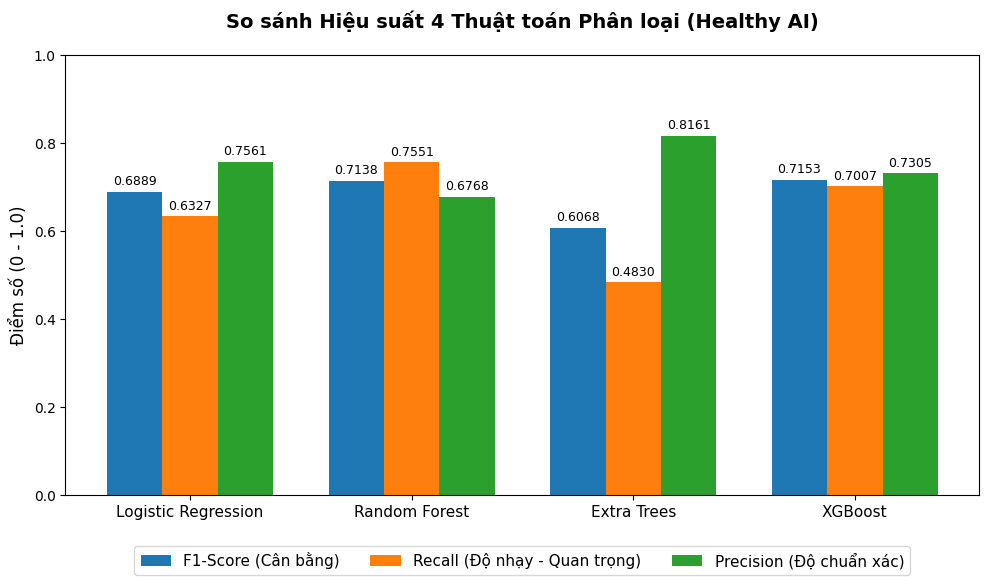

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Dữ liệu từ báo cáo của bạn
models = ['Logistic Regression', 'Random Forest', 'Extra Trees', 'XGBoost']
f1_scores = [0.6889, 0.7138, 0.6068, 0.7153]
recalls = [0.6327, 0.7551, 0.4830, 0.7007]
precisions = [0.7561, 0.6768, 0.8161, 0.7305]

# Thiết lập vị trí các cột
x = np.arange(len(models))
width = 0.25  # Độ rộng của cột

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, f1_scores, width, label='F1-Score (Cân bằng)', color='#1f77b4')
rects2 = ax.bar(x, recalls, width, label='Recall (Độ nhạy - Quan trọng)', color='#ff7f0e')
rects3 = ax.bar(x + width, precisions, width, label='Precision (Độ chuẩn xác)', color='#2ca02c')

# Tùy chỉnh biểu đồ
ax.set_ylabel('Điểm số (0 - 1.0)', fontsize=12)
ax.set_title('So sánh Hiệu suất 4 Thuật toán Phân loại (Healthy AI)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.set_ylim(0, 1.0)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3, fontsize=11)

# Thêm số liệu trên đầu mỗi cột
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # offset theo chiều dọc
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.savefig('model_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()